In [1]:
from argopy import DataFetcher as ArgoDataFetcher
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from matplotlib import pyplot as plt

/home/jcherry/Documents/storage/git/argo-data-interpolation/.venv/bin/python: No module named pip


In [2]:
from argo_interp.cycle import CycleError, ModelError, SensorError, CycleSettings, CycleModel

from argo_interp.cycle import build_model, calc_fold_error

In [3]:
box = [
    -75, -45, ## Longitude min/max
    20, 30, ## Latitude min/max
    0, 3000, ## Pressure/depth min/max
    '2011-01', '2011-06', ## Datetime min/max
]
f = ArgoDataFetcher().region(box).load()
data = f.data.to_dataframe()

In [4]:
group_col = 'PLATFORM_CYCLE'
group_fields = ['PLATFORM_NUMBER', 'CYCLE_NUMBER']
cycle_fields = ['LATITUDE', 'LONGITUDE', 'TIME']
reading_fields = ['PRES', 'PRES_ERROR', 'PSAL', 'PSAL_ERROR', 'TEMP', 'TEMP_ERROR']

In [5]:
cycles = data[group_fields + cycle_fields].drop_duplicates().sort_values(group_fields)
cycles.index = (cycles[group_fields[0]].astype(str) + '-' + cycles[group_fields[1]].astype(str)).rename('PLATFORM_CYCLE')

In [6]:
readings = data[group_fields + reading_fields].drop_duplicates().sort_values([*group_fields, 'PRES']).reset_index(drop=True)
readings.insert(0, group_col, readings[group_fields[0]].astype(str) + '-' + readings[group_fields[1]].astype(str))
readings = readings.drop(columns=group_fields)

In [7]:
settings = CycleSettings(
    prominence = 0.25,
    window = 10,
    spacing = 5.0,
    peak_dist = 20,
    folds = 5,
)

cycle_models = {}
for cycle_number, cycle_data in tqdm(readings.groupby('PLATFORM_CYCLE')):
    cycle_data = cycle_data.sort_values('PRES')
    rmse_temp, rmse_sal = calc_fold_error(cycle_data, settings)

    model_temp = build_model(cycle_data['PRES'], cycle_data['TEMP'], settings)
    model_sal = build_model(cycle_data['PRES'], cycle_data['PSAL'], settings)

    cycle_error = CycleError(model=ModelError(
        temperature=rmse_temp,
        salinity=rmse_sal
    ))
    cycle_model = CycleModel(
        temperature=build_model(cycle_data['PRES'], cycle_data['TEMP'], settings),
        salinity=build_model(cycle_data['PRES'], cycle_data['PSAL'], settings),
        error=cycle_error,
        settings=settings,
        pressure_bounds=(cycle_data['PRES'].min(), cycle_data['PRES'].max()),
    )
    cycle_models[cycle_number] = cycle_model

  0%|          | 0/469 [00:00<?, ?it/s]

In [8]:
model_error = pd.DataFrame([model.error.model for model in cycle_models.values()])

In [9]:
cycle_number = np.random.choice(list(cycle_models.keys()))
print(f"Cycle #: {cycle_number}")
cycle_data = readings.loc[readings['PLATFORM_CYCLE'] == cycle_number]
cycle_model = cycle_models[cycle_number]

Cycle #: 6900551-71


In [10]:
cycle_interp = cycle_model.interpolate(cycle_data['PRES'])

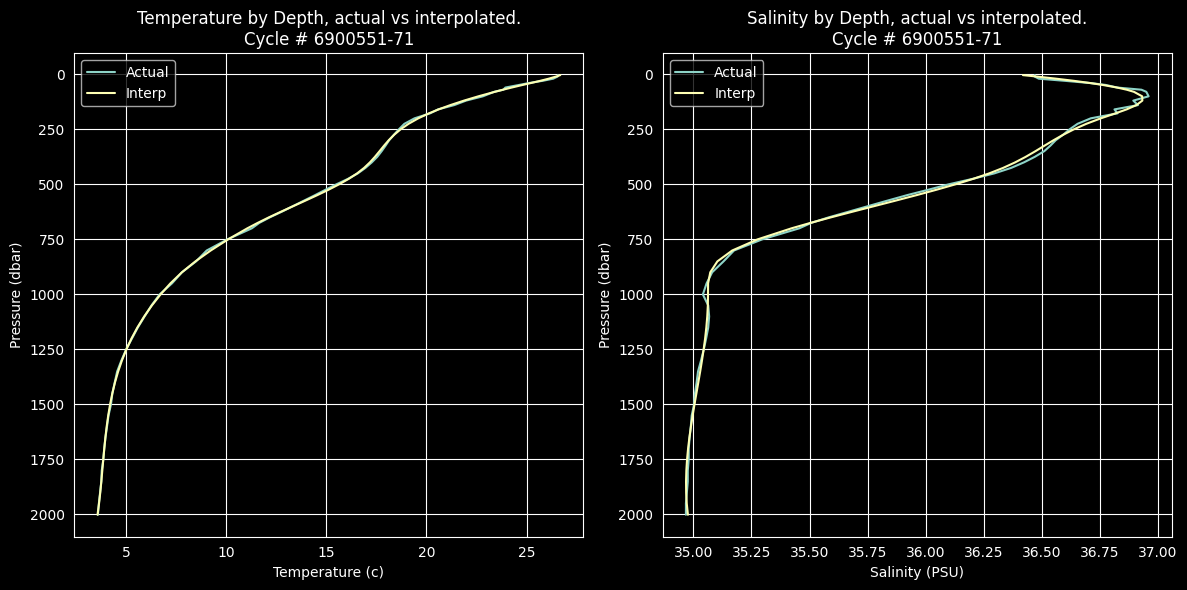

In [13]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

cycle_data.plot(x='TEMP', y='PRES', ax=ax[0])
cycle_interp.reset_index().plot(x='temperature', y='pressure', ax=ax[0])
ax[0].set(
    title=f"Temperature by Depth, actual vs interpolated."
          f"\nCycle # {cycle_number}",
    xlabel=f"Temperature (c)",
    ylabel=f"Pressure (dbar)",
)
ax[0].invert_yaxis()
ax[0].legend(["Actual", "Interp"])

cycle_data.plot(x='PSAL', y='PRES', ax=ax[1])
cycle_interp.reset_index().plot(x='salinity', y='pressure', ax=ax[1])
ax[1].set(
    title=f"Salinity by Depth, actual vs interpolated."
          f"\nCycle # {cycle_number}",
    xlabel=f"Salinity (PSU)",
    ylabel=f"Pressure (dbar)",
)
ax[1].invert_yaxis()
ax[1].legend(["Actual", "Interp"])

fig.tight_layout()